# Video of voltages at neuron locations

Plot each neuron at its location and color points by the (smoothed) membrane voltage at a given timestep.
Frames are rendered directly from Matplotlib and assembled into a video with OpenCV.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from buryn_utils import location_utils, voltage_utils
from utils import graphics

graphics.set_matplotlib_settings()


In [2]:
BURYNOUTPUTS_DIR = '../data/buryn_data/buryn_outputs_0'
LOCATIONS_PATH_E = Path(BURYNOUTPUTS_DIR + '/locations/group_e_locations.txt')
LOCATIONS_PATH_I = Path(BURYNOUTPUTS_DIR + '/locations/group_i_locations.txt')
VOLTAGES_PATH = Path(BURYNOUTPUTS_DIR + '/recordings/voltages_step0.txt')
OUTPUT_VIDEO = Path(BURYNOUTPUTS_DIR + '/videos/voltages_locations_smoothed.mp4')
FPS = 15
SMOOTHING_WINDOW = 200
FRAME_COUNT = 600
VOLTAGE_CMAP = 'coolwarm'

for path in (LOCATIONS_PATH_E, LOCATIONS_PATH_I, VOLTAGES_PATH):
    if not path.exists():
        raise FileNotFoundError(f'Could not find {path.resolve()}')


In [3]:
neuron_ids_e, neuron_locations_e = location_utils.load_neuron_locations(LOCATIONS_PATH_E)
neuron_ids_i, neuron_locations_i = location_utils.load_neuron_locations(LOCATIONS_PATH_I)

location_map = {int(neuron_id): location for neuron_id, location in zip(neuron_ids_e, neuron_locations_e)}
location_map.update(
    {int(neuron_id): location for neuron_id, location in zip(neuron_ids_i, neuron_locations_i)}
)

steps, voltages, neuron_ids = voltage_utils.load_voltage_recording(VOLTAGES_PATH)

available_indices = [idx for idx, neuron_id in enumerate(neuron_ids) if neuron_id in location_map]
if not available_indices:
    raise ValueError('No voltage-recorded neuron IDs were found in the location files.')

recorded_neuron_ids = [neuron_ids[idx] for idx in available_indices]
recorded_locations = np.array([location_map[neuron_id] for neuron_id in recorded_neuron_ids])
recorded_voltages = voltages[:, available_indices]

print(f'Loaded {len(steps)} timesteps for {len(recorded_neuron_ids)} neuron(s)')


Loaded 50000 timesteps for 301 neuron(s)


In [4]:
window = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW
smoothed_voltages = np.apply_along_axis(
    lambda m: np.convolve(m, window, mode='same'),
    axis=0,
    arr=recorded_voltages,
)

frame_indices = np.linspace(0, len(steps) - 1, num=FRAME_COUNT, dtype=int)
frame_indices = np.unique(frame_indices)

print(f'Voltage array shape: {recorded_voltages.shape}')
print(f'Smoothed voltage shape: {smoothed_voltages.shape}')
print(f'Frame count: {len(frame_indices)}')


Voltage array shape: (50000, 301)
Smoothed voltage shape: (50000, 301)
Frame count: 600


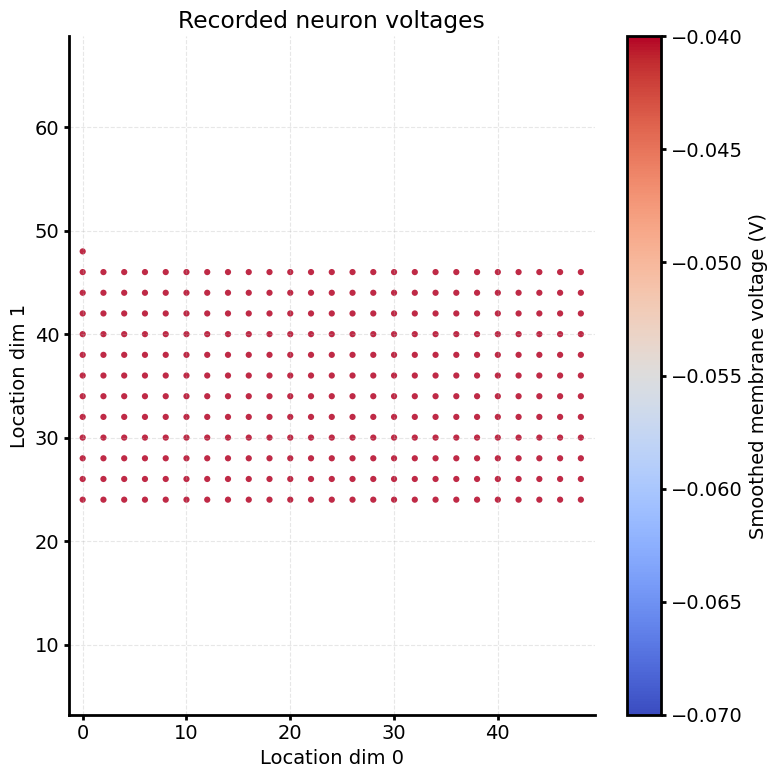

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap(VOLTAGE_CMAP)

voltage_min = -0.07
voltage_max = -0.04
norm = plt.Normalize(vmin=voltage_min, vmax=voltage_max)
colors = cmap(norm(smoothed_voltages[frame_indices[0]]))
scatter = ax.scatter(
    recorded_locations[:, 0],
    recorded_locations[:, 1],
    c=colors,
    s=20,
    alpha=0.85,
    edgecolors='none',
)

ax.set_title('Recorded neuron voltages')
ax.set_xlabel('Location dim 0')
ax.set_ylabel('Location dim 1')
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.3)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Smoothed membrane voltage (V)')


In [6]:
scatter.set_cmap(cmap)
scatter.set_norm(norm)
fig.canvas.draw()
w, h = fig.canvas.get_width_height()

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, FPS, (w, h))

for frame_idx in frame_indices:
    step = steps[frame_idx]
    frame_voltages = smoothed_voltages[frame_idx]
    scatter.set_array(frame_voltages)
    ax.set_title(f'Recorded neuron voltages (step {step})')

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
    bgr = cv2.cvtColor(buf, cv2.COLOR_RGBA2BGR)
    video.write(bgr)

video.release()
print(f'Saved video to {OUTPUT_VIDEO.resolve()}')


Saved video to /home/hi/coding/buryn_simulation/../data/buryn_data/buryn_outputs_0/videos/voltages_locations_smoothed.mp4
